In [5]:
## Packages Import
import numpy             as np
import matplotlib.pyplot as plt

In [ ]:
class VortexLatticeSolver:
    """
    Vortex lattice method
    """
    #--------------------#
    #   Initialization   #
    #--------------------#
    def __init__(self, b, lamb, delta, sym,
                n=100):
        # Wing geometry
        self.span     = b       # wing span                 [m]
        self.sweep    = lamb    # quarter-chord sweep angle [rad]
        self.dihedron = delta   # dihedral angle            [rad]
        self.symmetric = sym    # symmetric wing

        # Discretization
        self.N = n         # number of lattices
        self.c_4 = None    # quarter-chord line

    
    #-------------#
    #   Methods   #
    #-------------#
    def _unit_rot(self, v, theta, ax):
        """
        Elemental clockwise rotation of the reference system axes.
        
        v     -> vector componets - shape: (N, 3)
        theta -> rotation angle - clockwise rotation: theta>0
        ax    -> rotation axis index
        """
        # Assemble rotation matrix
        rot = np.zeros((3, 3))  # rotation matrix
        # diagonal elements
        rot[ax, ax] = 1.0
        rot[ax-1, ax-1] = np.cos(theta)
        rot[ax-2, ax-2] = np.cos(theta)
        # extra-diagonal elements
        rot[ax-2, ax-1] = -np.sin(theta)
        rot[ax-1, ax-2] = np.sin(theta)

        # Apply rotation
        v_rot = np.sum(rot[None, :, :] * v[:, None, :], axis=2)
        return v_rot



    def _build_mesh(self):
        """
        Discretization of the wing by a finite number of lattices.
        """
        b     = self.span
        lamb  = self.sweep
        delta = self.dihedron

        if self.symmetric:
            s_min, s_max = 0.0, b/2
        else:
            s_min, s_max = -b/2, b/2

        # Spanwise wing discretization
        s = np.linspace(s_min, s_max, (self.N+1))

        # Express wing points in earth reference frame
        coord_wing = np.column_stack((np.zeros_like(s), np.zeros_like(s), s))   # wing frame
        coord_dihed = self._unit_rot(coord_wing, lamb, 1)                       # dihedral frame
        coord_earth = self._unit_rot(coord_dihed, delta, 0)                     # earth frame

        self.c_4 = coord_earth



In [ ]:
## Parameters Definition

# Wing geometries
B = 10.0      # wing span                 [m]
L = 30.0      # quarter-chord sweep angle [deg]
D = -10.0     # dihedral angle            [deg]

SYM = True   # symmetric wing configuration

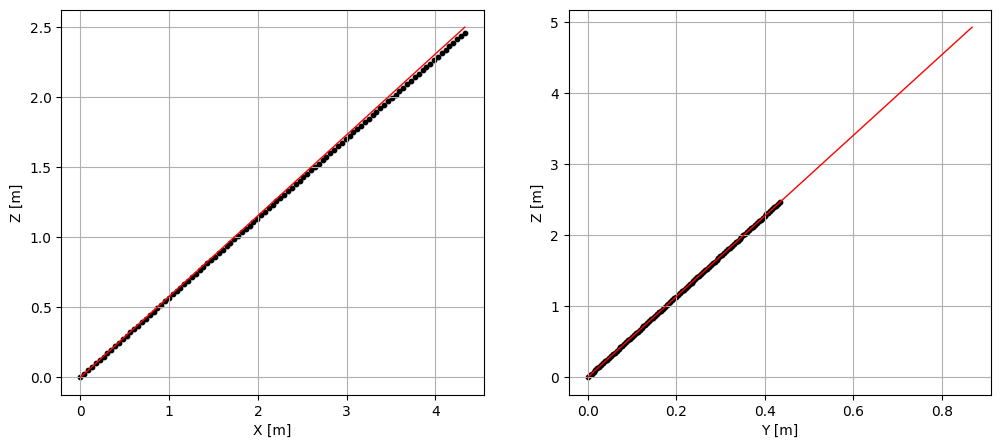

In [ ]:
## TEST

# Wing discretization and attitude
vlm = VortexLatticeSolver(b=B,
                        lamb=np.deg2rad(L),
                        delta=np.deg2rad(D),
                        sym=SYM)
vlm._build_mesh()

x_plot = vlm.c_4[:, 0]
y_plot = vlm.c_4[:, 1]
z_plot = vlm.c_4[:, 2]

fig_test = plt.figure(figsize=(12, 5))
# Plot wing - lateral view
ax1 = fig_test.add_subplot(1, 2, 1)
ax1.scatter(x_plot, z_plot, c='k', s=10)
ax1.plot([0, (B/2) * np.sin(np.deg2rad(L))], [0, (B/2) * np.cos(np.deg2rad(L))],
        color='r',
        linewidth=1)
ax1.set_xlabel("X [m]")
ax1.set_ylabel("Z [m]")
ax1.grid(True)
# Plot wing - frontal view
ax2 = fig_test.add_subplot(1, 2, 2)
ax2.scatter(y_plot, z_plot, c='k', s=10)
ax2.plot([0, -(B/2) * np.sin(np.deg2rad(D))], [0, (B/2) * np.cos(np.deg2rad(D))],
        color='r',
        linewidth=1)
ax2.set_xlabel("Y [m]")
ax2.set_ylabel("Z [m]")
ax2.grid(True)